# Projeto 7 – Filtros Digitais
**Camada Física da Computação – Engenharia da Computação**  
Prof. Rodrigo Carareto

---

In [1]:
# Imports necessários
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, iirpeak, iirnotch, freqz, tf2zpk, TransferFunction
from IPython.display import Audio

## O que é um filtro digital?

É como se fosse uma "peneira" de frequências. Um sinal de áudio é composto por várias senoides sobrepostas (graves, médios, agudos). O filtro processa esse sinal, amostra por amostra, e produz um sinal de saída onde certas frequências foram atenuadas ou amplificadas.

## Exercício 1

Grave ou gere matematicamente com frequência de amostragem de **44100 Hz** um sinal com alguns poucos segundos de duração que possua componentes (harmônicos) acima de 500 Hz.

- Mostre o **FFT** desse sinal, evidenciando que ele possui componentes acima de 500 Hz.
- Em seguida, implemente o filtro passa-baixa do exemplo (Butterworth, corte em 500 Hz) e faça a filtragem do sinal original.
- Mostre o **FFT do sinal filtrado** verificando que as frequências acima de 500 Hz foram atenuadas.
- Reproduza o áudio original e o filtrado. Consegue perceber a diferença? O que notou de diferente?

O filtro do exemplo tem a seguinte função de transferência:

$$G(Z) = \frac{0{,}00120741\, Z^2 + 0{,}00241481\, Z + 0{,}00120741}{Z^2 - 1{,}8993342\, Z + 0{,}90416304}$$

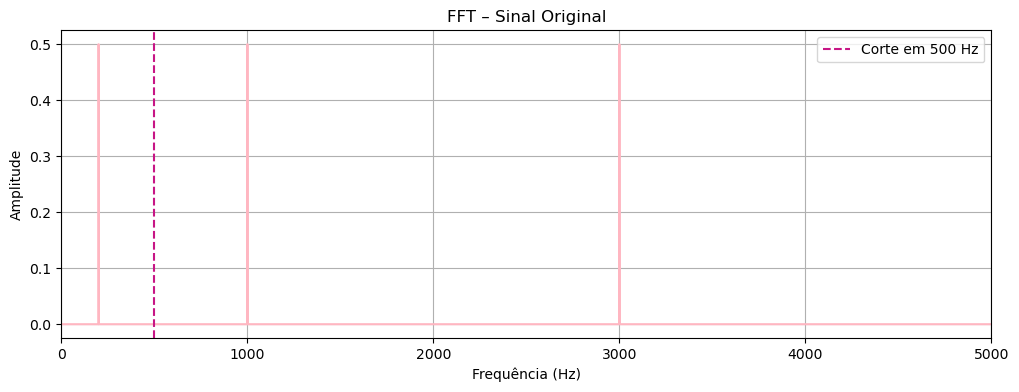

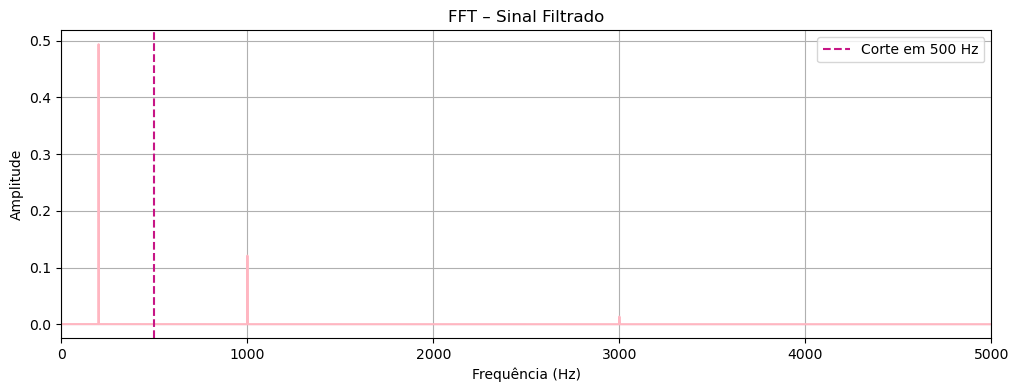

Áudio original:


Áudio filtrado:


In [7]:
# Exercício 1 – Geração do sinal, FFT e aplicação do filtro passa-baixa
fs = 44100 # amostras por segundo
duracao = 2 # segundos
t = np.linspace(0, duracao, int(fs * duracao), endpoint=False) # vetor de tempo
# representa cada instante da amostragem

# Sinal original: soma de senóides de freqs diferentes
sinal = (np.sin(2 * np.pi * 200 * t) +   # 200 Hz  – grave (passa)
         np.sin(2 * np.pi * 1000 * t) +   # 1000 Hz – médio (bloqueado)
         np.sin(2 * np.pi * 3000 * t))    # 3000 Hz – agudo (bloqueado)

# FFT do sinal original: decompõe o sinal do dominio do tempo p dominio da frequencia
N = len(sinal)
fft_original = np.abs(np.fft.rfft(sinal)) / N # dividimos por N p normalizar a amplitude
freqs = np.fft.rfftfreq(N, d=1/fs)

plt.figure(figsize=(12, 4))
plt.plot(freqs, fft_original, color = 'lightpink')
plt.title('FFT – Sinal Original')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 5000)
plt.axvline(500, color='mediumvioletred', linestyle='--', label='Corte em 500 Hz')
plt.legend()
plt.grid()
plt.show()

# Aplicando filtro passa baixa Butterworth (corte em 500Hz)
# O filtro Butterworth tem resposta maximamente plana na banda de passagem.
# - N=2: ordem do filtro (quanto maior, mais abrupta a queda após o corte)
# - Wn=500: frequência de corte em Hz
# - btype='low': tipo passa-baixa
# b e a são os coeficientes do numerador e denominador da função de transferência G(Z).
b, a = butter(N=2, Wn=500, btype='low', fs=fs)
sinal_filtrado = lfilter(b, a, sinal)
# lfilter percorre o sinal amostra por amostra aplicando os coeficientes b e a.

fft_filtrado = np.abs(np.fft.rfft(sinal_filtrado)) / N

plt.figure(figsize=(12, 4))
plt.plot(freqs, fft_filtrado, color = 'lightpink')
plt.title('FFT – Sinal Filtrado')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 5000)
plt.axvline(500, color='mediumvioletred', linestyle='--', label='Corte em 500 Hz')
plt.legend()
plt.grid()
plt.show()

# Reprodução do áudio
print("Áudio original:")
display(Audio(sinal, rate=fs))

print("Áudio filtrado:")
display(Audio(sinal_filtrado, rate=fs))

**Resposta (observações sobre a diferença entre os áudios):**

O sinal gerado é composto por três senóides: 200 Hz, 1000 Hz e 3000 Hz.
O FFT do sinal original confirma essa composição, exibindo três picos de
amplitude 0,5 igualmente distribuídos. Após a aplicação do filtro passa-baixa
Butterworth de ordem 2 com frequência de corte em 500 Hz, o FFT do sinal
filtrado mostra que apenas o componente de 200 Hz — abaixo do corte — passou
integralmente. Os componentes de 1000 Hz e 3000 Hz foram progressivamente
atenuados, com o de 3000 Hz praticamente eliminado. Isso demonstra o
comportamento típico de um filtro passa-baixa: ele age como uma "peneira"
que bloqueia frequências acima da frequência de corte, com a atenuação
crescendo conforme a frequência se afasta do ponto de corte. Perceptivamente,
o áudio filtrado soa mais abafado, pois os componentes agudos foram removidos,
restando apenas o grave de 200 Hz.

---
## Exercício 2

Expresse em dB:
- A intensidade **limiar da audição**: $I = 10^{-12}\, W/m^2$
- A intensidade **limiar da dor**: $I = 100\, W/m^2$

Fórmula utilizada para intensidade acústica:

$$I_{dB} = 10 \cdot \log\left(\frac{I}{10^{-12}}\right)$$

In [8]:
# Exercício 2 – Cálculo dos valores em dB
# O decibel eh uma escala logaritmica usada p representar razões
# entre grandezas. p intensidade sonora, usamos como ref o limiar da audição
# humana (10^-12 W/m²), que corresponde a 0 dB.

I_ref = 1e-12  # limiar da audição (W/m²) — referência da escala

I_audicao = 1e-12 # limiar da audicao
I_dor = 100 # limiar da dor 

dB_audicao = 10 * np.log10(I_audicao / I_ref)
dB_dor     = 10 * np.log10(I_dor / I_ref)

print(f"Limiar da audição: {I_audicao} W/m² → {dB_audicao:.1f} dB")
print(f"Limiar da dor:     {I_dor} W/m² → {dB_dor:.1f} dB")

Limiar da audição: 1e-12 W/m² → 0.0 dB
Limiar da dor:     100 W/m² → 140.0 dB


---
## Exercício 3

Um filtro tem como entrada o sinal $U(t) = 20\, \text{sen}(1000\pi\, t)$ e como saída $Y(t) = 10\, \text{sen}(1000\pi\, t)$.

**Qual o ganho em dB desse filtro para esse sinal de entrada?**

> *Obs.: pensando em sinais senoidais, as tensões de entrada e saída são as amplitudes dos respectivos sinais.*

Fórmula para ganho de sinais elétricos/áudio:

$$G_{dB} = 20 \cdot \log\left(\frac{V_{saída}}{V_{entrada}}\right)$$

In [9]:
# Exercício 3 – Cálculo do ganho em dB
# Qnd tratamos de sinais eletricos ou de audio, o ganho do sistema
# eh expresso como a razao entre a amplitude do sinal de saida e a 
# de entrada

# Como a intensidade eh proporcional ao quadrado da amplitude, 
# a formula usa o fator 20 ao inves de 10

V_entrada = 20  # amplitude do sinal de entrada
V_saida   = 10  # amplitude do sinal de saída

ganho_dB = 20 * np.log10(V_saida / V_entrada)

print(f"Amplitude de entrada: {V_entrada}")
print(f"Amplitude de saída:   {V_saida}")
print(f"Ganho do filtro:      {ganho_dB:.2f} dB")

Amplitude de entrada: 20
Amplitude de saída:   10
Ganho do filtro:      -6.02 dB


*Interpretação: o sinal entrou com amplitude 20 e saiu com amplitude 10, ou seja, o filtro cortou a amplitude pela metade. O sinal negativo indica atenuação – o filtro enfraqueceu o sinal.*

---
## Exercício 4a

Considere o filtro utilizado no Exercício 1 e seu diagrama de Bode.

- Caso o sinal de entrada seja $U(t) = 50\, \text{sen}(10^4\, t)$, qual seria a **amplitude do sinal de saída**?
- Caso o sinal de entrada seja $U(t) = 50\, \text{sen}(10^3\, t)$, qual seria a **amplitude do sinal de saída**?

> *Dica: converta as frequências de rad/s para Hz e consulte o diagrama de Bode para estimar o ganho em dB em cada frequência.*

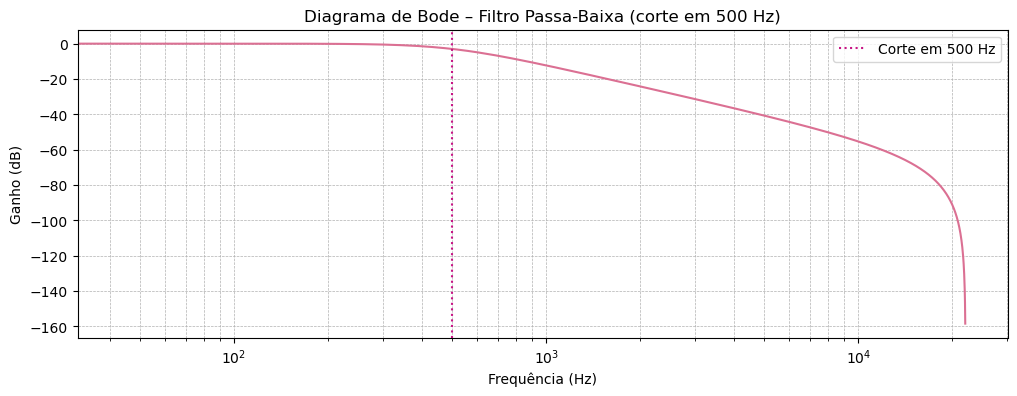

In [11]:
# Plot do diagrama de Bode do ex.1
# O diagrama mostra o ganho do filtro em dB p cada frequência.
# Com ele conseguimos prever como o filtro se comporta para qualquer sinal
# de entrada, sem precisar aplicá-lo — basta ler o ganho na frequência desejada.

w, h = freqz(b, a, fs=fs)

plt.figure(figsize=(12, 4))
plt.semilogx(w, 20 * np.log10(abs(h)), color='palevioletred')
plt.title('Diagrama de Bode – Filtro Passa-Baixa (corte em 500 Hz)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Ganho (dB)')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.axvline(500, color='mediumvioletred', linestyle=':', label='Corte em 500 Hz')
plt.legend()
plt.show()

**Intepretação:**
- **Abaixo de 500Hz: o ganho eh praticamente 0db – o filtro deixa o sinal passar sem atenuar quase nada;**

- **Em 500Hz: eh onde o filtro começa a cair – essa eh a frequência de corte;**

- **Acima de 500Hz: o ganho cai progressivamente e de forma cada vez mais acentudada – quanto mais longe do corte, mais o filtro atenua.**

In [12]:
# Exercício 4a – Estimativa das amplitudes de saída a partir do diagrama de Bode

# Os sinais de entrada estão em rad/s, então precisamos converter para Hz:
# f = ω / (2π)
# U(t) = 50 sen(10⁴ t) → ω = 10⁴ rad/s → f = 10⁴ / (2π) ≈ 1592 Hz
# U(t) = 50 sen(10³ t) → ω = 10³ rad/s → f = 10³ / (2π) ≈  159 Hz

f1 = 1e4 / (2 * np.pi)  # ≈ 1592 Hz
f2 = 1e3 / (2 * np.pi)  # ≈  159 Hz

# Encontrando o ganho em dB para cada frequência no diagrama de Bode
ganho_f1 = 20 * np.log10(abs(h[np.argmin(abs(w - f1))]))
ganho_f2 = 20 * np.log10(abs(h[np.argmin(abs(w - f2))]))

# Convertendo ganho em dB para razão linear e calculando amplitude de saída
# V_saida = V_entrada * 10^(G_dB / 20)
amplitude_entrada = 50

saida_f1 = amplitude_entrada * 10**(ganho_f1 / 20)
saida_f2 = amplitude_entrada * 10**(ganho_f2 / 20)

print(f"Para U(t) = 50 sen(10⁴ t)  →  f ≈ {f1:.1f} Hz")
print(f"  Ganho: {ganho_f1:.2f} dB  →  Amplitude de saída ≈ {saida_f1:.4f}")

print(f"\nPara U(t) = 50 sen(10³ t)  →  f ≈ {f2:.1f} Hz")
print(f"  Ganho: {ganho_f2:.2f} dB  →  Amplitude de saída ≈ {saida_f2:.4f}")

Para U(t) = 50 sen(10⁴ t)  →  f ≈ 1591.5 Hz
  Ganho: -20.24 dB  →  Amplitude de saída ≈ 4.8617

Para U(t) = 50 sen(10³ t)  →  f ≈ 159.2 Hz
  Ganho: -0.06 dB  →  Amplitude de saída ≈ 49.6519


**Interpretação: no primeiro, o filtro atenuou bastante pois essa frequência está bem aicma do corte de 500Hz. No segundo, a amplitude está praticamente intacta, pois a frequência está bem abaixo do corte, então passa quase sem nenhuma atenuação**

---
## Exercício 4b

Em filtros passa-baixa, define-se a **frequência de corte** como a frequência em que se tem uma atenuação de **−6 dB**.

- Estime a frequência de corte do filtro passa-baixa do exemplo a partir do diagrama de Bode.
- Qual seria a relação entre a **amplitude de saída** e a **amplitude de entrada** para um sinal com frequência igual à frequência de corte?

In [ ]:
# Exercício 4b – Frequência de corte e relação de amplitudes
# A frequência de corte eh definida como o ponto onde a atenuação é de -6 dB.
# Nesse ponto, a amplitude de saída cai para metade da amplitude de entrada.
# V_saida / V_entrada = 10^(-6/20) ≈ 0.5

# Encontrando a frequência onde o ganho é mais próximo de -6 dB
ganho_corte = -6
idx_corte = np.argmin(abs(20 * np.log10(abs(h)) - ganho_corte))
f_corte = w[idx_corte]

razao = 10**(ganho_corte / 20)

print(f"Frequência de corte estimada: {f_corte:.1f} Hz")
print(f"Relação V_saida / V_entrada na frequência de corte: {razao:.4f} ≈ 0.5")

Frequência de corte estimada: 646.0 Hz
Relação V_saida / V_entrada na frequência de corte: 0.5012 ≈ 0.5


**Interpretação: A frequência de corte estimada foi **646 Hz** — ligeiramente acima dos 500 Hz configurados. Isso é normal, pois o `freqz` tem resolução finita e o ponto exato de −6 dB pode cair entre dois pontos do vetor `w`. Na prática, o filtro Butterworth de ordem 2 tem sua frequência de corte real um pouco deslocada dependendo da definição usada pelo `butter` do scipy.**

**A relação **V_saída/V_entrada = 0,5** confirma a teoria: na frequência de corte, a amplitude cai exatamente para **metade** do valor de entrada, o que corresponde a **−6 dB**.**

---
## Exercício 5 – Filtro Passa-Faixa

O código abaixo (`filtro_passa_faixa.ipynb`) fornece a função de transferência discreta $G_Z$ de um filtro digital **passa-faixa**. O filtro foi calculado para passar apenas frequências próximas de **2 kHz** (frequência central). Além disso, o código também faz o diagrama de Bode do filtro.

- Rode o código e **altere o valor do parâmetro Q** (chamado fator de qualidade).
- **Descreva como esse parâmetro atua.**

/var/folders/kg/qyth0_y12bb695l5916wkwx00000gn/T/ipykernel_90628/2925967358.py:26: RuntimeWarning: divide by zero encountered in log10
  plt.semilogx(w_bp, 20 * np.log10(abs(h_bp)), label=f'Q = {Q}')


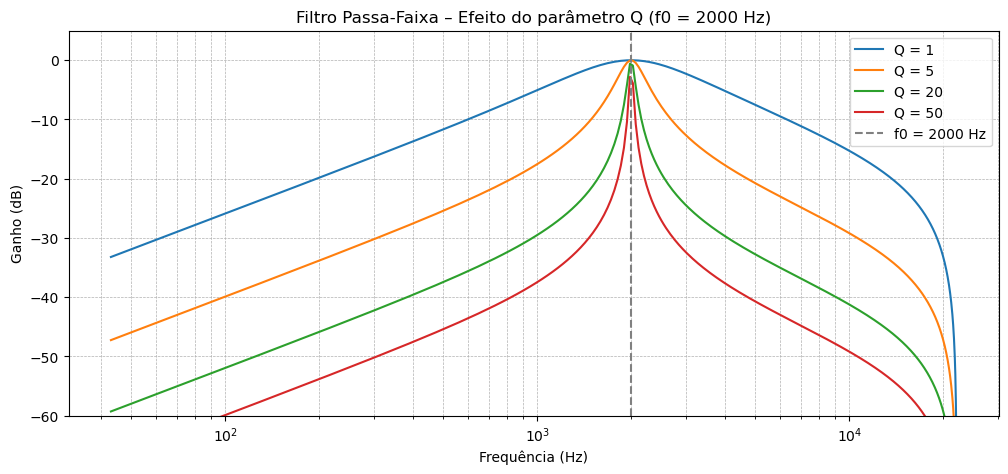

In [15]:
# Exercício 5 – Filtro passa-faixa com diferentes valores de Q
# Código base do fornecido (filtro_passa_faixa.ipynb):

fs = 44100            # Sampling rate (Hz)
f0 = 2000             # Center frequency (Hz)
valores_Q = [1, 5, 20, 50]  # diferentes valores de Q para comparação

plt.figure(figsize=(12, 5))

# Para cada valor de Q, projetamos um filtro diferente e plotamos sua resposta.
# Assim conseguimos comparar o efeito do Q num único gráfico.
for Q in valores_Q:
    
    # iirpeak projeta o filtro passa-faixa (biquad).
    # w0 recebe a frequência normalizada: f0 dividido pela frequência de Nyquist (fs/2).
    # A frequência de Nyquist é o limite máximo representável com essa taxa de amostragem.
    # Q define a seletividade do filtro.
    # Retorna b e a: coeficientes do numerador e denominador da função de transferência.
    b_bp, a_bp = iirpeak(w0=f0/(fs/2), Q=Q)
    
    # freqz calcula a resposta em frequência do filtro a partir dos coeficientes b e a.
    # Retorna w (vetor de frequências em Hz) e h (resposta complexa em cada frequência).
    w_bp, h_bp = freqz(b_bp, a_bp, fs=fs)
    
    # Plotamos o módulo de h em dB: 20*log10(|h|) é o ganho do filtro em cada frequência.
    plt.semilogx(w_bp, 20 * np.log10(abs(h_bp)), label=f'Q = {Q}')

plt.title('Filtro Passa-Faixa – Efeito do parâmetro Q (f0 = 2000 Hz)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Ganho (dB)')
# Linha vertical marcando a frequência central — o pico de todos os filtros deve estar aqui.
plt.axvline(f0, color='gray', linestyle='--', label='f0 = 2000 Hz')
plt.ylim(-60, 5)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

**O que todas as curvas têm em comum:**
> Todas atingem o pico de **0 dB em 2000 Hz** — a frequência central f0 sempre passa integralmente, independente do Q.

**O efeito do Q em cada curva:**

> - **Q = 1 (azul):** faixa muito larga — frequências bem distantes de 2000 Hz ainda passam com pouca atenuação. O filtro é pouco seletivo.
> - **Q = 5 (laranja):** já mais seletivo, a faixa passante começa a se estreitar visivelmente.
> - **Q = 20 (verde):** faixa bem mais estreita, frequências um pouco afastadas de 2000 Hz já são bastante atenuadas.
> - **Q = 50 (vermelho):** faixa extremamente estreita e precisa — só frequências muito próximas de 2000 Hz passam.

**A relação com a teoria Q = f0 / BW:**
> Quanto maior o Q, menor a largura de banda BW e mais seletivo o filtro. A frequência central não se desloca com Q — apenas a largura da faixa passante muda. Nas bandas de rejeição, a atenuação aumenta conforme Q cresce.

**Conclusão:** 
> O parâmetro Q controla a **largura da faixa de passagem** do filtro passa-faixa.

---
## Exercício 6 – Filtro Notch (Rejeita-Faixa)

O código abaixo (`filtro_notch.ipynb`) fornece a função de transferência discreta $G_Z$ de um filtro digital **rejeita-faixa**. O filtro foi calculado para **rejeitar** frequências próximas de **2 kHz** (frequência central). Além disso, o código também faz o diagrama de Bode do filtro.

- Rode o código e **altere o valor do parâmetro Q** (chamado fator de qualidade). Descreva como esse parâmetro atua.
- **Altere a frequência central.** 
- Você consegue pensar em alguma **utilidade para o filtro**?

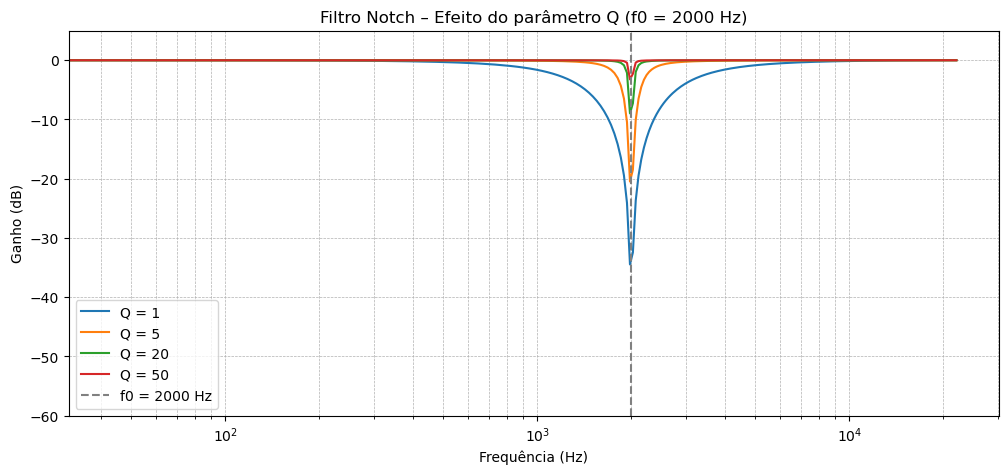

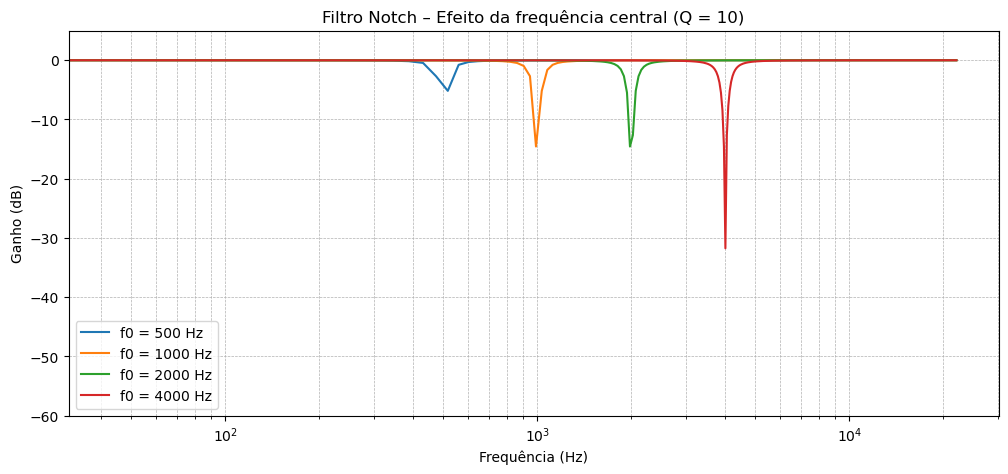

In [16]:
# Exercício 6 – Filtro Notch (Rejeita-Faixa): efeito do parâmetro Q e da frequência central

# O filtro notch faz o oposto do passa-faixa: rejeita frequências próximas à
# frequência central f0 e deixa passar todas as outras.
# O parâmetro Q controla a largura da faixa rejeitada: Q = f0 / BW.
# Quanto maior o Q, mais estreita e precisa é a faixa de rejeição.

fs = 44100
f0 = 2000  # frequência central (Hz)

# --- Parte 1: efeito do Q ---
valores_Q = [1, 5, 20, 50]

plt.figure(figsize=(12, 5))

for Q in valores_Q:
    # iirnotch projeta o filtro rejeita-faixa.
    # Diferente do iirpeak, aqui a frequência já é passada em Hz diretamente.
    b_n, a_n = iirnotch(f0, Q, fs)
    w_n, h_n = freqz(b_n, a_n, fs=fs)
    plt.semilogx(w_n, 20 * np.log10(abs(h_n) + 1e-10), label=f'Q = {Q}')

plt.title('Filtro Notch – Efeito do parâmetro Q (f0 = 2000 Hz)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Ganho (dB)')
plt.axvline(f0, color='gray', linestyle='--', label='f0 = 2000 Hz')
plt.ylim(-60, 5)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# --- Parte 2: efeito de alterar a frequência central ---
Q = 10  # Q fixo para comparar só o efeito de f0
frequencias = [500, 1000, 2000, 4000]

plt.figure(figsize=(12, 5))

for f0_var in frequencias:
    b_n, a_n = iirnotch(f0_var, Q, fs)
    w_n, h_n = freqz(b_n, a_n, fs=fs)
    plt.semilogx(w_n, 20 * np.log10(abs(h_n) + 1e-10), label=f'f0 = {f0_var} Hz')

plt.title('Filtro Notch – Efeito da frequência central (Q = 10)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Ganho (dB)')
plt.ylim(-60, 5)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

**Descrição do efeito do parâmetro Q:**

> *O parâmetro Q controla a largura da faixa de rejeição do filtro notch. Todos os filtros rejeitam a mesma freq central (2000Hz), mas com larguras diferentes:*
> - **Q = 1 (azul):** faixa de rejeição larga — frequências relativamente distantes de 2000 Hz já são atenuadas.
> - **Q = 5 (laranja):** rejeição mais seletiva, a "fenda" começa a se estreitar.
> - **Q = 20 (verde):** faixa de rejeição bem estreita, apenas frequências próximas de 2000 Hz são afetadas.
> - **Q = 50 (vermelho):** rejeição extremamente precisa e cirúrgica — só frequências muito próximas de 2000 Hz são eliminadas, o restante passa praticamente intacto.

**Profundidade e largura do notch para diferentes valores de Q:**

| Q  | Largura da rejeição | Profundidade em f0 |
|----|--------------------|--------------------|
| 1  | Larga              | ~35 dB             |
| 5  | Média              | ~60 dB             |
| 20 | Estreita           | ~60 dB             |
| 50 | Muito estreita     | ~60 dB             |


> **Conclusão:** O fator Q controla a **largura da faixa rejeitada** do notch — quanto maior o Q, mais cirúrgica e precisa é a rejeição.

**Efeito de alterar a frequência central:**

> *Alterar f0 simplesmente **desloca a fenda de rejeição** para outra posição no espectro, sem alterar o formato da curva. O filtro continua se comportando da mesma forma — a única diferença é qual frequência está sendo eliminada. Isso permite apontar o filtro para qualquer interferência específica no sinal.*

**Utilidades práticas do filtro notch:**

> - Eliminar a interferência da rede elétrica (60 Hz no Brasil) que contamina gravações de áudio e sinais de sensores.
> - Remover o feedback de microfone** em sistemas de som ao vivo, apontando o filtro para a frequência do chiado.
> - Suprimir interferências de radiofrequência** em sistemas de comunicação.